# Fitz Nagumo System

## Generate Data & Fit Basis

#### Imports & Config

In [28]:
normalization = 1e-2

training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .01 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

import numpy as np
import config
config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t

In [29]:
import sys
sys.path.append("../helpers")
sys.path.append("helpers")

import os
import h5py
import numpy as np

import opinf

import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

%matplotlib inline

### Generate & Visualize Data

In [30]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain.shape, true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 1.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.45 s.


((801,), (1024, 801), (400,), (1024, 400))

In [31]:
x = np.linspace(0, 1, true_states.shape[0])
fig, ax = plt.subplots()
line, = plt.plot(x, true_states[:,0])

def update(frame):
    line.set_data(x, true_states[:, frame])
    return line,

ani = FuncAnimation(
    fig,
    update,
    frames=100,
    interval=50,    # delay between frames in milliseconds
    blit=True       # only redraw the bits that change (faster)
)

plt.close(fig)              # << stop inline backend from showing the static plot
HTML(ani.to_jshtml())   # or .to_html5_video()

### Fit Basis

In [32]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...

Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.08 s.


In [33]:
from jax.scipy.special import gammaln
import jax.numpy as jnp

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

In [34]:
import numpy as np
import random
import time
import opinf

### Generate Prior For operator matrix
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    model=JaxCompatibleModel(
        operators="cAHBN",
        solver=opinf.lstsq.L2Solver(regularizer=1e-6),
    )
).fit(states=snapshots_sampled, inputs=inputs)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)
prior_ohat = rom.model.operator_matrix

# Put the operator in the ROM
rom.model._extract_operators(np.array(prior_ohat))

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
    input_func=input_func
)
deter_sol = rom.model.predict_result_
print(deter_sol.t.shape)          
# print(deter_sol.message) 

if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
    print('Found stable operator')
else:
    print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
    raise RuntimeError

(512, 400) (512, 400)
(400,)
Found stable operator


## Run Model & Visualize Results

### Bayesian GP

#### Define and Run Model

Starting SVI optimization...
Iteration 0: loss = 130901.3359
Iteration 100: loss = 50632.0391
Iteration 200: loss = 24756.4258
Iteration 300: loss = 22022.3320
Iteration 400: loss = 15621.5215
Iteration 500: loss = 13079.5332
Iteration 600: loss = 11613.3467
Iteration 700: loss = 8293.0781
Iteration 800: loss = 8500.4893
Iteration 900: loss = 5786.4922
Iteration 1000: loss = 5213.6216
Iteration 1100: loss = 4533.4224
Iteration 1200: loss = 4673.2900
Iteration 1300: loss = 4307.5366
Iteration 1400: loss = 5214.9541
Iteration 1500: loss = 3627.0923
Iteration 1600: loss = 3920.7944
Iteration 1700: loss = 2710.5049
Iteration 1800: loss = 3543.1975
Iteration 1900: loss = 2854.2681
Iteration 2000: loss = 3217.4810
Iteration 2100: loss = 2511.6899
Iteration 2200: loss = 2698.6006
Iteration 2300: loss = 2594.8076
Iteration 2400: loss = 2530.5771
Iteration 2500: loss = 2144.5264
Iteration 2600: loss = 2203.4336
Iteration 2700: loss = 1995.7849
Iteration 2800: loss = 2154.2632
Iteration 2900: lo

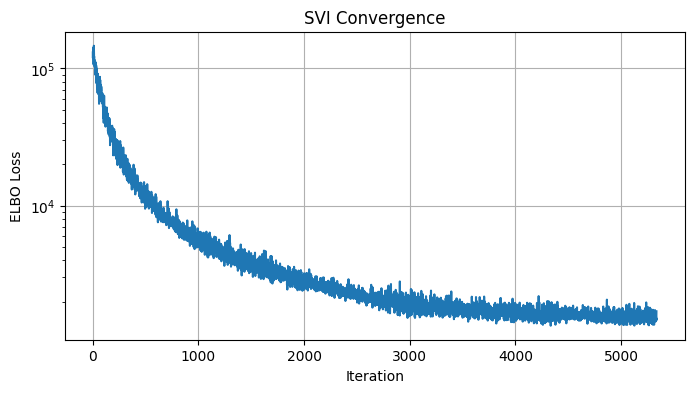

In [35]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        chi: float = 1e-6, 
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[0]
    numPODmodes = qhat.shape[0]
    
    # Get time scale
    time_range = time.max() - time.min()
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(numPODmodes):
        # Analyze data scale
        data_std = jnp.std(qhat[i])
        
        # For oscillatory data, we need small lengthscales
        # Start with a prior centered at ~1/20th of the time range
        lengthscale = numpyro.sample(f"lengthscale{i}", 
                                     dist.LogNormal(jnp.log(time_range/20), 1.0))
        Ls.append(lengthscale)
        
        # Variance based on data variance
        variance = numpyro.sample(f"variance{i}", 
                                 dist.LogNormal(jnp.log(data_std**2), 0.5))
        Vars.append(variance)
        
        # Small noise since data looks clean
        noise = numpyro.sample(f"noise{i}", 
                              dist.LogNormal(-8.0, 1.0))  # Very small noise
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time, time, lengthscale, variance)
        
        # Add tiny regularization for numerical stability
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])

# Create autoguide
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=30)

# Setup optimizer - start with higher learning rate and decay
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop with patience
num_iterations = 20000  # More iterations
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

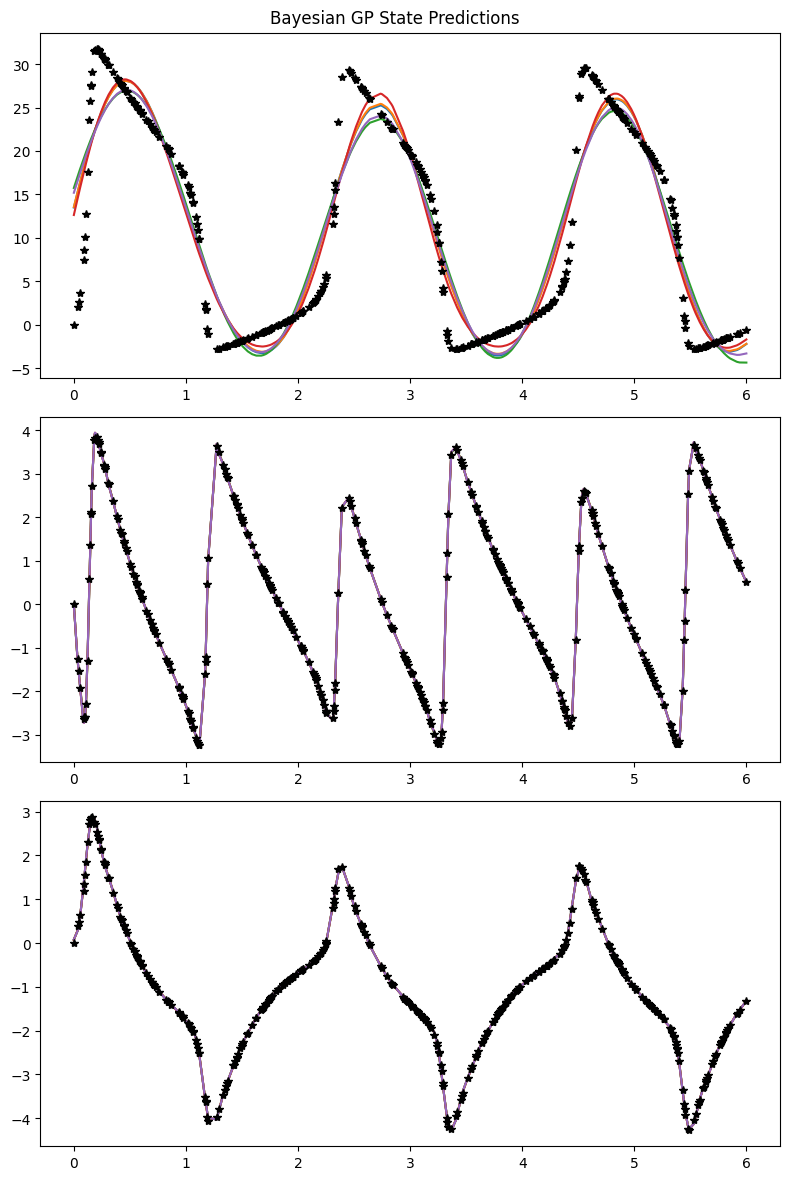

In [36]:
from bgp_jax import BayesianGP
import random

fig, ax = plt.subplots(numPODmodes, 1, figsize = (8,12))

num_pulls = 5

for i in range(num_pulls):
    rand_idx = random.randint(0, len(samples['lengthscale0']))
    Ls = np.array([samples[f'lengthscale{i}'][rand_idx] for i in range(numPODmodes)])
    Vs = np.array([samples[f'variance{i}'][rand_idx] for i in range(numPODmodes)])
    Ns = np.array([samples[f'noise{i}'][rand_idx] for i in range(numPODmodes)])

    gp = BayesianGP()
    gp.X_train = time_domain_sampled[:, None]
    for j in range(numPODmodes):
        gp.y_train = snapshots_compressed[j]
        mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        ax[j].plot(time_domain_sampled, mean)

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

fig.suptitle("Bayesian GP State Predictions")
fig.tight_layout()

In [37]:
### Compute mean and std of each thing that we need

Ls_means = np.array([samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)])
Ls_covs = np.array([jnp.cov(samples[f'lengthscale{i}']) for i in range(numPODmodes)])
Ls_stds = np.array([samples[f'lengthscale{i}'].std() for i in range(numPODmodes)])
Vs_means = np.array([samples[f'variance{i}'].mean() for i in range(numPODmodes)])
Vs_covs = np.array([jnp.cov(samples[f'variance{i}']) for i in range(numPODmodes)])
Vs_stds = np.array([samples[f'variance{i}'].std() for i in range(numPODmodes)])
Ns_means = np.array([samples[f'noise{i}'].mean() for i in range(numPODmodes)])
Ns_stds = np.array([samples[f'noise{i}'].std() for i in range(numPODmodes)])
Ns_covs = np.array([jnp.cov(samples[f'noise{i}']) for i in range(numPODmodes)])
Fs_means = np.array([samples[f'f{i}'].mean(axis=0) for i in range(numPODmodes)])

Ls_means.shape, Ls_stds.shape, Vs_means.shape, Vs_stds.shape, Ns_means.shape, Ns_stds.shape, Fs_means.shape

((3,), (3,), (3,), (3,), (3,), (3,), (3, 400))

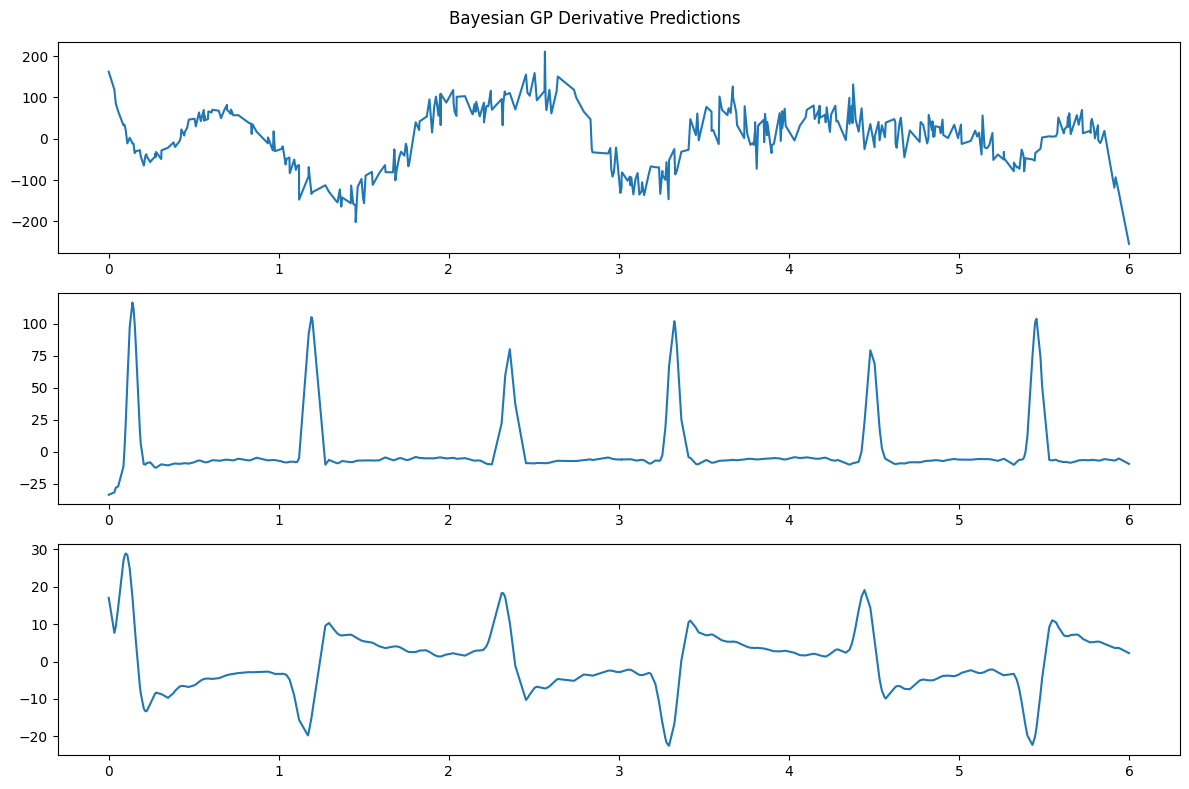

In [38]:
# Now let's check the derivative predictions
from bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 
mu_z_modes = []
for i in range(numPODmodes):
    lengthscale = Ls_means[i]
    variance = Vs_means[i]
    Xi = Fs_means[i]
    # Cache inverse computation
    Kyy = get_c_phi(lengthscale, variance, time_domain_sampled[:,None], 1e-4)
    Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(time_domain_sampled.shape[0]))
    Ds = get_dash_c_phi(lengthscale, variance, time_domain_sampled[:,None]) @ Kyy_inv
    mu_z_j  = Ds @ Xi             # (num_time_steps,)
    mu_z_modes.append(mu_z_j)

mu_z_all = jnp.stack(mu_z_modes)               # (numPODmodes, num_time_steps)

fig, ax = plt.subplots(numPODmodes, 1, figsize=(12,8))
for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, mu_z_all[i])

fig.suptitle("Bayesian GP Derivative Predictions")
fig.tight_layout()

### Bayesian Latent State

#### Define and Run Model

Starting SVI optimization...
Iteration 0: loss = 535235200.0000
Iteration 100: loss = 479161376.0000
Iteration 200: loss = 433369888.0000
Iteration 300: loss = 394125888.0000
Iteration 400: loss = 358571264.0000
Iteration 500: loss = 325995232.0000
Iteration 600: loss = 296088672.0000
Iteration 700: loss = 269564704.0000
Iteration 800: loss = 243900512.0000
Iteration 900: loss = 221110432.0000
Iteration 1000: loss = 199649264.0000
Iteration 1100: loss = 180018016.0000
Iteration 1200: loss = 162256464.0000
Iteration 1300: loss = 145545648.0000
Iteration 1400: loss = 130291680.0000
Iteration 1500: loss = 116255056.0000
Iteration 1600: loss = 103848680.0000
Iteration 1700: loss = 92209392.0000
Iteration 1800: loss = 81888352.0000
Iteration 1900: loss = 71883936.0000
Iteration 2000: loss = 63295880.0000
Iteration 2100: loss = 55666360.0000
Iteration 2200: loss = 48647184.0000
Iteration 2300: loss = 42433192.0000
Iteration 2400: loss = 36798644.0000
Iteration 2500: loss = 31794700.0000
Iter

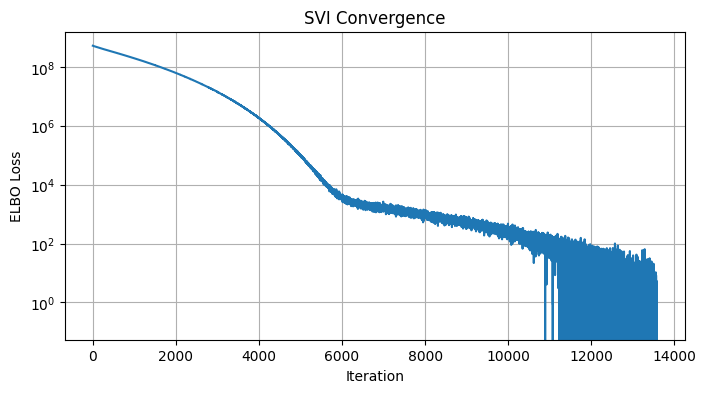

In [39]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()

def model(time, qhat, chi, normalization=1e-6):
    num_time_steps = time.shape[0]

    for i in range(numPODmodes):
        # Get hyperparameter statistics
        lengthscale_mean = Ls_means[i]
        lengthscale_std = Ls_stds[i]
        variance_mean = Vs_means[i]
        variance_std = Vs_stds[i]
        noise_mean = Ns_means[i]
        noise_std = Ns_stds[i]
        # fixed hyperparameters
        lengthscale_log_mean = jnp.log(lengthscale_mean**2 / jnp.sqrt(lengthscale_mean**2 + lengthscale_std**2))
        lengthscale_log_std = jnp.sqrt(jnp.log(1 + lengthscale_std**2 / lengthscale_mean**2))
        
        variance_log_mean = jnp.log(variance_mean**2 / jnp.sqrt(variance_mean**2 + variance_std**2))
        variance_log_std = jnp.sqrt(jnp.log(1 + variance_std**2 / variance_mean**2))
        
        noise_log_mean = jnp.log(noise_mean**2 / jnp.sqrt(noise_mean**2 + noise_std**2))
        noise_log_std = jnp.sqrt(jnp.log(1 + noise_std**2 / noise_mean**2))
        
        # Sample positive hyperparameters
        lengthscale = numpyro.sample(
            f"L{i}",
            dist.LogNormal(lengthscale_log_mean, lengthscale_log_std)
        )
        variance = numpyro.sample(
            f"V{i}",
            dist.LogNormal(variance_log_mean, variance_log_std)
        )
        noise = numpyro.sample(
            f"N{i}",
            dist.LogNormal(noise_log_mean, noise_log_std)
        )

        norm = normalization
        for _ in range(5):
            Kyy = get_c_phi(lengthscale, variance, time, norm)
            try:
                L = jnp.linalg.cholesky(Kyy)   # <-- capture the factor
                break
            except jnp.linalg.LinAlgError:
                norm *= 10.
        else:
            raise RuntimeError(f"Mode {i}: could not find a PSD covariance after 5 tries")

        # 2) sample using the scale_tril argument (no re-validation of covariance_matrix)
        Xi = numpyro.sample(
            f"Xi{i}",
            dist.MultivariateNormal(
                loc=jnp.zeros(num_time_steps),
                scale_tril=L           # <-- use the L directly
            )
        )
        numpyro.sample(f"Yi{i}",
                    dist.Normal(Xi, chi),
                    obs=qhat[i])
        

# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
guide = autoguide.AutoNormal(model)

# Setup optimizer
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization = normalization
                                  )
    return svi_state, loss

# Training loop
num_iterations = 20000  # Adjust as needed
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

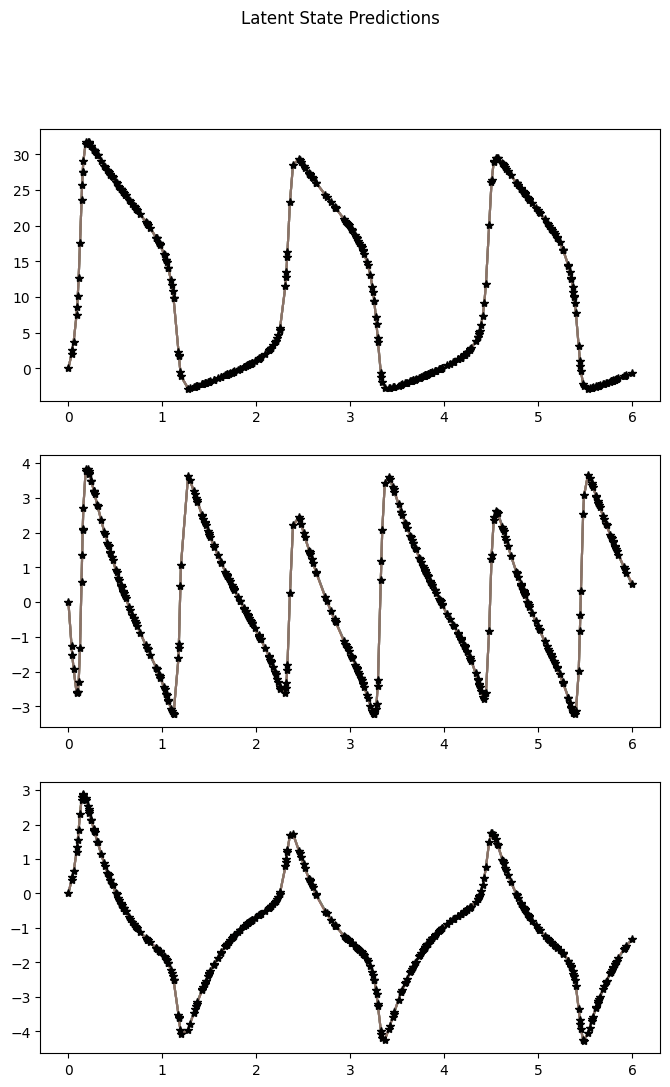

In [40]:
num_pulls = 25
trajs = []
deriv_trajs = []
Xss = []

for i in range(num_pulls):
    rand_idx = random.randint(0, len(samples['Xi0']))
    Xs = np.array([samples[f'Xi{i}'][rand_idx] for i in range(numPODmodes)])
    Xss.append(Xs)

fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

for i in range(len(Xss)):
    for j in range(numPODmodes):
        ax[j].plot(deter_sol.t, Xss[i][j], alpha =.2)

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, snapshots_compressed[i], 'k*')

fig.suptitle("Latent State Predictions")
plt.show()

### Bayesian Gradient Matching

#### Define and Run Model

Starting SVI optimization...
Iteration 0: loss = 5375884.0000
Iteration 100: loss = 4719520.0000
Iteration 200: loss = 4255437.0000
Iteration 300: loss = 3940403.5000
Iteration 400: loss = 3588671.2500
Iteration 500: loss = 3214803.5000
Iteration 600: loss = 2959186.2500
Iteration 700: loss = 2540124.5000
Iteration 800: loss = 2510287.2500
Iteration 900: loss = 2322124.0000
Iteration 1000: loss = 1824751.3750
Iteration 1100: loss = 1726343.2500
Iteration 1200: loss = 1607000.1250
Iteration 1300: loss = 1405853.7500
Iteration 1400: loss = 1453648.2500
Iteration 1500: loss = 1227989.6250
Iteration 1600: loss = 1050533.7500
Iteration 1700: loss = 854617.5000
Iteration 1800: loss = 960996.1875
Iteration 1900: loss = 706018.8750
Iteration 2000: loss = 656807.9375
Iteration 2100: loss = 597494.5625
Iteration 2200: loss = 471616.0000
Iteration 2300: loss = 447891.5000
Iteration 2400: loss = 390847.0938
Iteration 2500: loss = 357419.5625
Iteration 2600: loss = 277230.0000
Iteration 2700: loss 

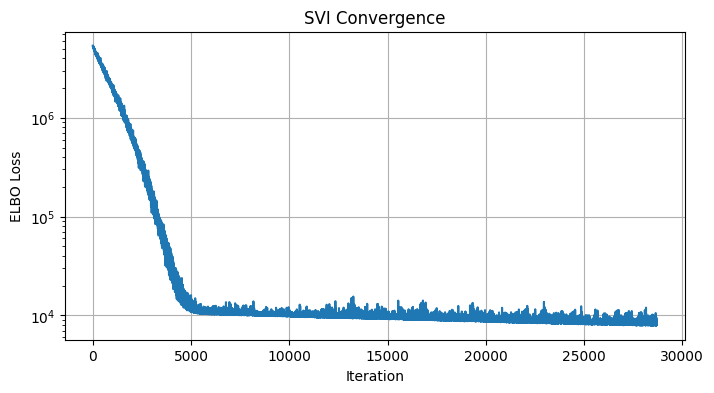

In [41]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()

Xs_means = np.stack(
    [samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)],
    axis=0
)
Xs_covs = np.stack(
    [np.cov(samples[f'Xi{i}'].T) for i in range(numPODmodes)],
    axis=0
)

def stable_cholesky(A, jitter=1e-6):
    """Compute Cholesky with automatic jitter for stability"""
    max_tries = 5
    for i in range(max_tries):
        try:
            L = jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))
            return L
        except:
            jitter *= 10
    return jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))

def stable_solve(A, b, jitter=1e-6):
    """Solve linear system with regularization"""
    return jnp.linalg.solve(A + jitter * jnp.eye(A.shape[0]), b)

def model(time, qhat, O_mean, chi, normalization=1e-6):
    num_time_steps = time.shape[0]

    O = numpyro.sample('O',
                    dist.Normal(jnp.zeros_like(O_mean), 10))

    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    
    for i in range(numPODmodes):
        # Priors for hyperparameters
        lengthscale = Ls_means[i]
        Ls.append(lengthscale)

        variance = Vs_means[i]
        Vars.append(variance)

        noise = Ns_means[i]
        noises.append(noise)
        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)

        Xs.append(
            numpyro.sample(
                f"X{i}",
                dist.MultivariateNormal(loc=Xs_means[i], covariance_matrix=Xs_covs[i]+normalization*jnp.eye(Xs_covs[i].shape[0])),
            )
        )

            
    inputs = input_func(time_domain_sampled)
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=inputs) @ O.T
    
    for i in range(numPODmodes):
        lengthscale = Ls[i]
        variance = Vars[i]
        Kyy = Kyys[i]
        Xi = Xs[i]
        
        # Cache inverse computation
        # Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(num_time_steps))
        Kyy_inv = stable_solve(Kyy, jnp.eye(num_time_steps), jitter=normalization)
        Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
        CDashs = get_c_phi_dash(lengthscale, variance, time)
        DashCs = get_dash_c_phi(lengthscale, variance, time)
        CPhis = get_c_phi(lengthscale, variance, time, nugget=normalization)
        CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
        # Use Cholesky decomposition for more stable inverse
        CPhis_chol = stable_cholesky(CPhis, jitter=normalization)
        A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
        mu_zi = Ds @ Xi
        # gamma = 1e0
        gamma = 1e0
        constraint_cov = A + gamma * jnp.eye(num_time_steps)
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=200)

# Setup optimizer
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     O_mean=prior_ohat,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed,
                                  O_mean=prior_ohat,
                                  chi=noiselevel,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop
num_iterations = 100000  # Adjust as needed
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     O_mean=prior_ohat,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

##### Comparision of Operators (Image)

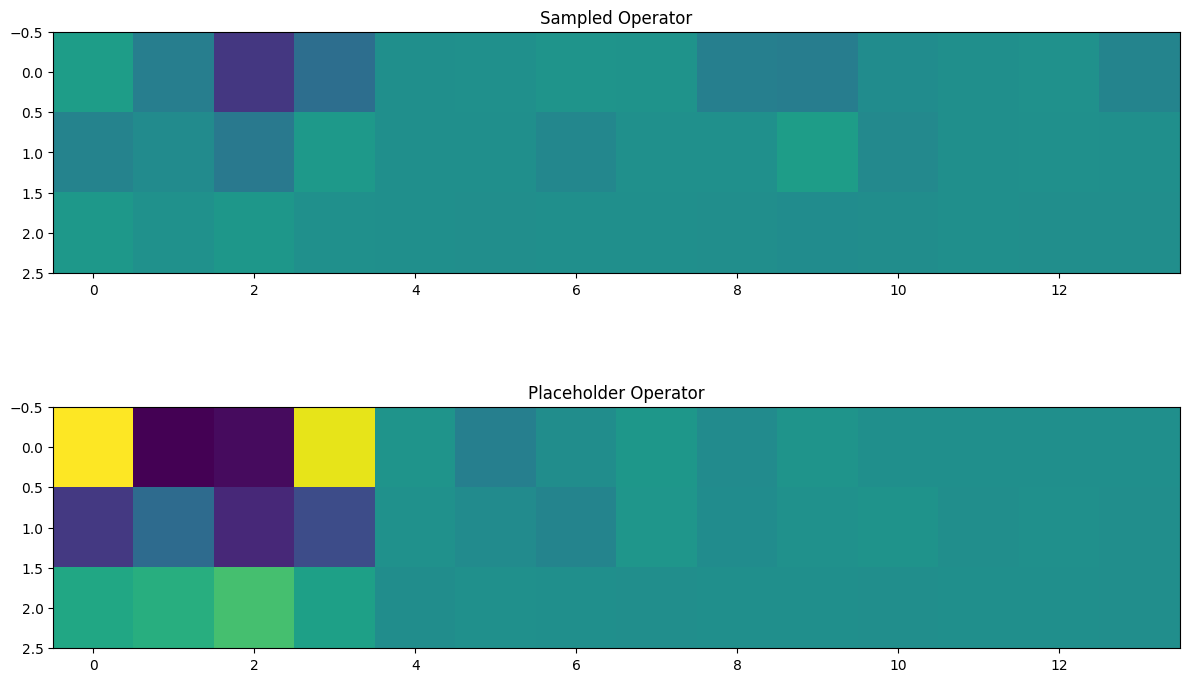

In [42]:
import random
import numpy as onp
import jax.numpy as jnp
import matplotlib.pyplot as plt

num_pulls = 500
trajs = []
deriv_trajs = []
zi_trajs = []
Xss = []
Os = []

for _ in range(num_pulls):
    # Pick a random posterior draw
    idx = random.randrange(len(samples['O']))
    
    # 1) Extract operator and state coefficients
    O_sample = samples['O'][idx]                   # (r x r) operator
    Os.append(O_sample)
    # Xi_samples = [samples[f'Xi{j}'][idx] for j in range(numPODmodes)]
    Xi_samples = Xs_means
    Xs_array = jnp.stack(Xi_samples)               # (numPODmodes,)
    Xss.append(Xs_array)

    # 2) Extract GP hyperparameters for each mode
    # lengthscales = [samples[f'lengthscale{j}'][idx] for j in range(numPODmodes)]
    lengthscales = Ls_means
    # variances    = [samples[f'variance{j}'][idx]    for j in range(numPODmodes)]
    variances = Vs_means
    # noise_levels = [samples[f'noise{j}'][idx]       for j in range(numPODmodes)]  # if you need them

    # 3) Compute mu_z for each mode and store full trajectory
    mu_z_modes = []
    for j in range(numPODmodes):
        ls  = lengthscales[j]
        var = variances[j]
        # recompute K_yy and its inverse
        Kyy     = get_c_phi(ls, var, time_domain_sampled[:, None], normalization)
        Kyy_inv = stable_solve(Kyy, jnp.eye(time_domain_sampled.shape[0]))
        # D matrix and mu_z
        Dj      = get_dash_c_phi(ls, var, time_domain_sampled[:, None]) @ Kyy_inv
        mu_z_j  = Dj @ Xi_samples[j]               # (num_time_steps,)
        mu_z_modes.append(mu_z_j)

    mu_z_all = jnp.stack(mu_z_modes)               # (numPODmodes, num_time_steps)
    zi_trajs.append(mu_z_all)

    # 4) Compute derivative trajectory from current sample
    inputs = input_func(time_domain_sampled)
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs_array, inputs=inputs) @ O_sample.T
    deriv_trajs.append(f_Xi_ohat)

    # 5) Insert operator into ROM and run deterministic prediction
    rom.model._extract_operators(onp.array(O_sample))
    rom.model.predict(state0=snapshots_compressed[:, 0], t=time_domain_sampled, input_func=input_func)
    deter_sol = rom.model.predict_result_

    # If it failed to match time grid, skip this draw
    if deter_sol.t.shape[0] != snapshots_compressed.shape[1]:
        print("Failed to find stable operator; skipping this sample.")
        continue

    trajs.append(deter_sol.y)  # (r x num_time_steps)

# 6) Quick sanity‐plot: first sampled operator vs placeholder
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
vmin = min(Os[0].min(), prior_ohat.min())
vmax = max(Os[0].max(), prior_ohat.max())

axes[0].imshow(Os[0],   vmin=vmin, vmax=vmax)
axes[0].set_title("Sampled Operator")
axes[1].imshow(prior_ohat, vmin=vmin, vmax=vmax)
axes[1].set_title("Placeholder Operator")
plt.tight_layout()
plt.show()

##### Trajectory Comparison Within Training Domain

(500, 3, 400)


Text(0.5, 0.98, 'Within Training Domain Trajectory')

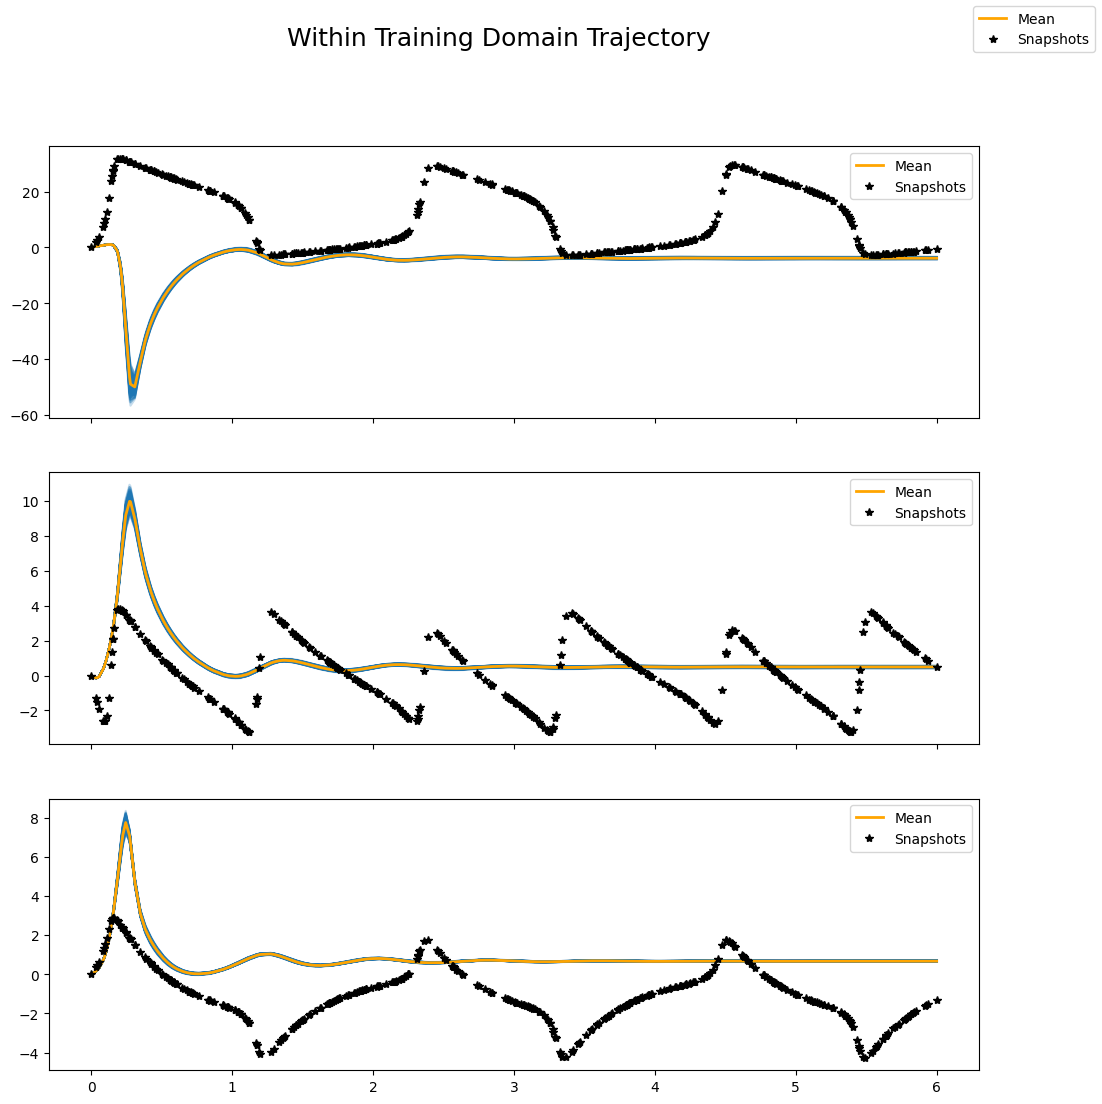

In [43]:
### Plot the mean trajectory
fig, ax = plt.subplots(numPODmodes,1, figsize = (12, 12), sharex=True)
trajs = np.array(trajs)
print(trajs.shape)
mean_trajs = trajs.mean(axis=0)
mean_trajs.shape

for i in range(len(trajs)):
    for j in range(numPODmodes):
        ax[j].plot(time_domain_sampled, trajs[i, j, :], alpha = .25, color='tab:blue')

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, mean_trajs[i], color = 'orange', lw = 2, label = 'Mean')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label = 'Snapshots')

for axis in ax:
    axis.legend()

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels)
fig.suptitle('Within Training Domain Trajectory', fontsize=18)

##### Trajectory Comparison Outside of training Domain

In [44]:
eval_time = np.linspace(0, 8, 801)

import random
import numpy as onp
import jax.numpy as jnp
import matplotlib.pyplot as plt

num_pulls = 250
trajs = []

for _ in range(num_pulls):
    # Pick a random posterior draw
    idx = random.randrange(len(samples['O']))
    
    # 1) Extract operator and state coefficients
    O_sample = samples['O'][idx]                   # (r x r) operator
    Os.append(O_sample)

    # 5) Insert operator into ROM and run deterministic prediction
    rom.model._extract_operators(onp.array(O_sample))
    rom.model.predict(state0=snapshots_compressed[:, 0], t=eval_time, input_func=input_func)
    deter_sol = rom.model.predict_result_

    # If it failed to match time grid, skip this draw
    if deter_sol.t.shape[0] != eval_time.shape[0]:
        print(deter_sol.t.shape)
        print("Failed to find stable operator; skipping this sample.")
        continue

    trajs.append(deter_sol.y)  # (r x num_time_steps)

trajs = np.array(trajs)
trajs.shape

(250, 3, 801)

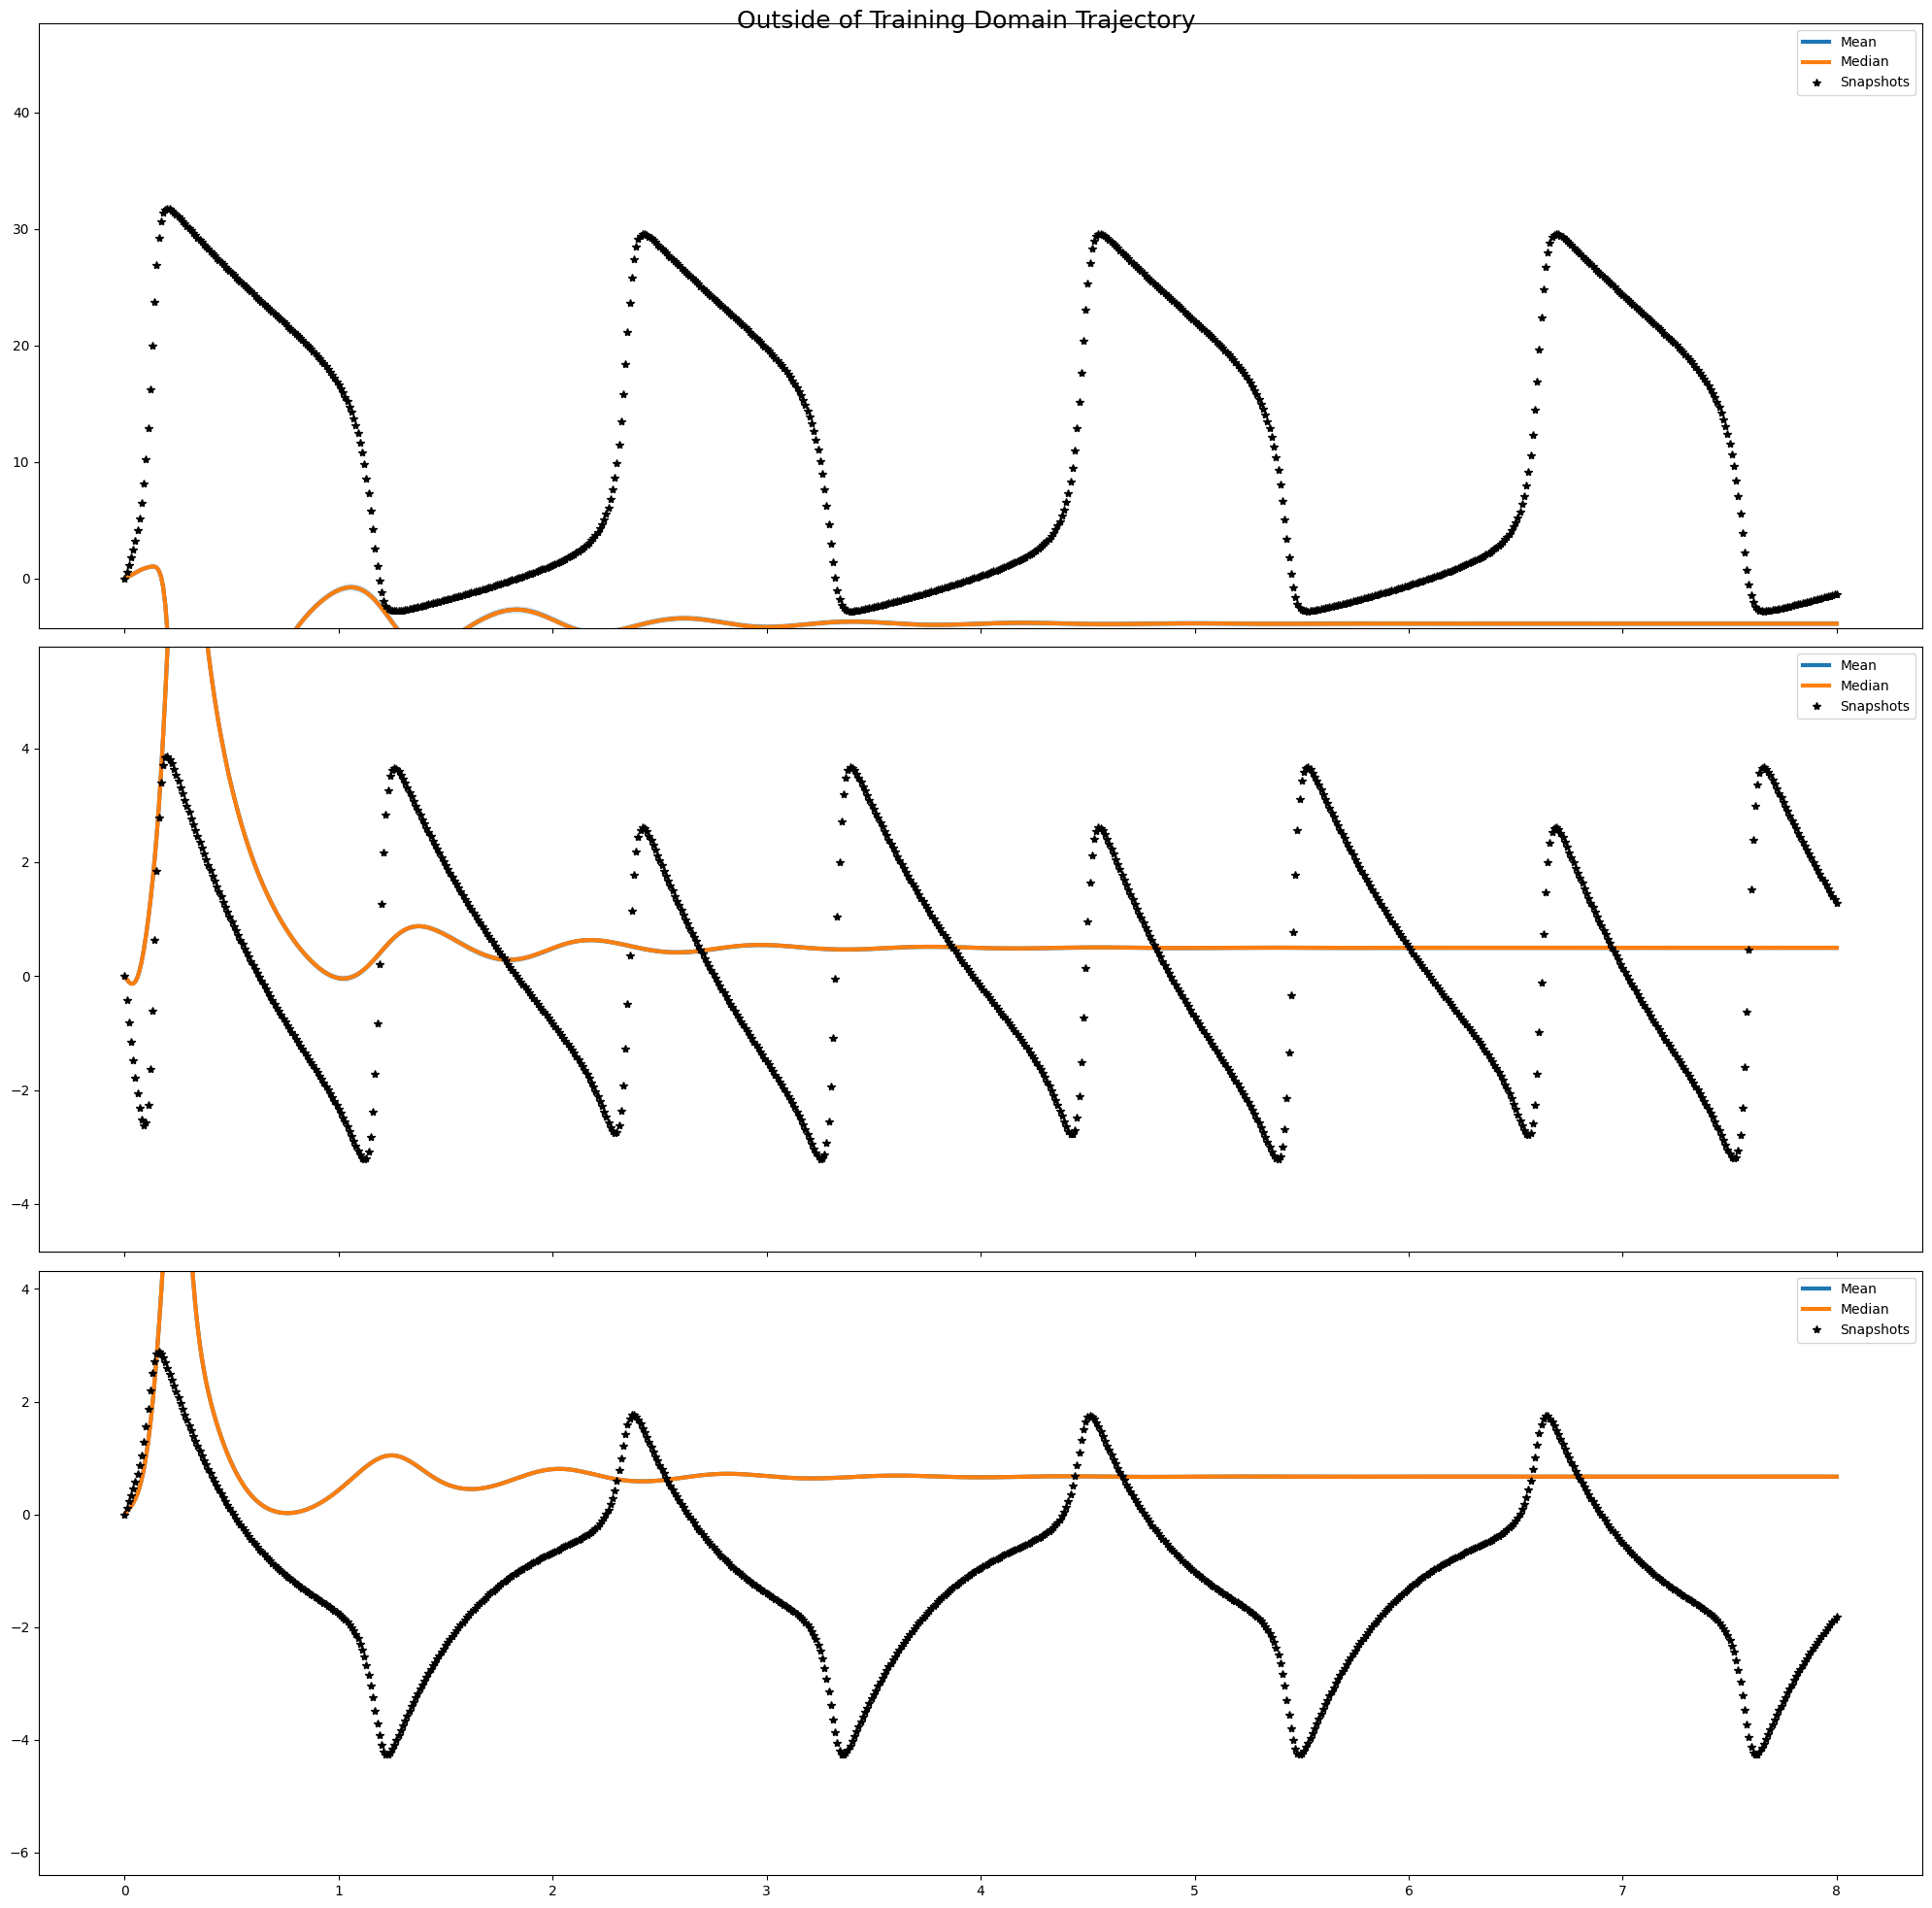

In [45]:
# choose percentiles (e.g. 5% and 95%)
lower_pct, upper_pct = 5, 95

# compute along axis=0 (the n samples)
lower = np.percentile(trajs, lower_pct, axis=0)  # shape (r, m)
upper = np.percentile(trajs, upper_pct, axis=0)  # shape (r, m)
mean  = np.mean(trajs, axis=0)
median = np.median(trajs, axis=0)

fig, ax = plt.subplots(numPODmodes, 1, figsize = (20,20), sharex=True)

for i in range(numPODmodes):
    ax[i].plot(eval_time, mean[i], label = 'Mean', lw=3)
    ax[i].plot(eval_time, median[i], label = 'Median', lw=3)
    ax[i].plot(eval_time, full_states_compressed[i], 'k*', lw=.05, label='Snapshots')
    ax[i].fill_between(eval_time, lower[i], upper[i], alpha=.2)
    ax[i].legend()
    ymin = max(full_states_compressed[i].min() * 1.5, -50)
    ymax = min(full_states_compressed[i].max() * 1.5,  50)
    ax[i].set_ylim(ymin, ymax)

fig.suptitle('Outside of Training Domain Trajectory', fontsize=18)
fig.tight_layout()